# Rigid Body Aircraft Dynamics

This is a summary of basic nonlinear aircraft dynamics intended to support a discussion of follow-on linearizations and response characteristics. Since this topic is well over a century old we have extensive published work to rely on. The ultimate goal of this series is to focus on items that I feel are underrepresented in current textbooks, in particular the characteristics of "body-heavy" configurations typical of high-speed aircraft, which feature high ratios of yaw to roll inertia that are commonly seen in high-speed delta wing configurations. For this section, beyond the use of a delta wing F-106 as a test case, the development of nonlinear equations of motion is entirely standard. 

These documents will be written inline with code as much as possible, which does disrupt the flow of reading but is intended to facilitate demonstration of the concepts under discussion. It also informs the ordering of the topics, which has us start with aircraft model descriptions and nonlinear simulation prior to moving into the "simpler" (supposedly) linearizations. Aircraft model data is taken from publicly available sources including in the references below.

### References
Online references will be used wherever possible, with selective textbook results referenced where necessary. Some useful online resources are:

- Prof. Caughey's 2011 MAE 570 Class Notes: https://courses.cit.cornell.edu/mae5070/
  - Derivation of the dynamic equations of motion is provided in Chapter 4: https://courses.cit.cornell.edu/mae5070/DynamicEquations.pdf
  - Description of the dynamic response is in Chapter 5: https://courses.cit.cornell.edu/mae5070/DynamicStability.pdf
  - Notes on control theory are in Chapter 6: https://courses.cit.cornell.edu/mae5070/Control.pdf
- An online version of the USAF TPS Textbook is quite comprehensive, although it is also fairly old and I have been warned it contains several errors (I do not have the errata available and haven't caught any myself yet)
  - Part 1 provides the background and basics through open-loop dynamic response and handling qualities https://apps.dtic.mil/sti/pdfs/ADA170959.pdf
  - Part 2 covers more advanced topics such as aeroelasticity, high-angle of attack and spin response, and closed loop control: https://apps.dtic.mil/sti/pdfs/ADA170960.pdf
- An excellent resource for aircraft stability and control derivatives is Heffley's NASA CR-2144: https://ntrs.nasa.gov/api/citations/19730003312/downloads/19730003312.pdf
- Subsonic S&C data for the F-106B is available in Suit & Batterson's NASA TM-87711. Some of the M0.9 data are suspect and there is a typo in the Ixz inertia term, but overall this is still a useful reference: https://ntrs.nasa.gov/api/citations/19860015232/downloads/19860015232.pdf
- Various aircraft mass properties and useful simulation notes are documented in Garza & Morelli's NASA TM-212145. The aerodynamic data was available publicly at one point but this is no longer the case: https://ntrs.nasa.gov/api/citations/20030013626/downloads/20030013626.pdf
- Add Kalviste body-frame paper

The textbooks I currently own and will refer to are:
- Etkin & Reid, Dynamics of Flight: Stability & Control 3rd Edition. This is personally very useful to me because it's the book I used for my undergraduate flight dynamics course, so I know where everything is if I need to look it up
  - The official 3rd edition is quite pricey online: https://www.amazon.com/Dynamics-Flight-Stability-Bernard-Etkin/dp/0471034185
  - An expanded version is available via Dover and is very affordable: https://www.amazon.com/Dynamics-Atmospheric-Flight-Aeronautical-Engineering/dp/0486445224
  - I won't link it but there is an easy to find PDF available online as well
- Stengel's Flight Dynamics: Second Edition; https://www.amazon.com/Flight-Dynamics-Robert-F-Stengel/dp/0691220255
- McRuer, Graham & Ashkenas Aircraft Dynamics & Automatic Control; https://www.amazon.com/Aircraft-Dynamics-Automatic-Control-Princeton/dp/0691600384
  - A PDF of this book is also available on DTIC: https://apps.dtic.mil/sti/tr/pdf/AD0859330.pdf


## Nonlinear Aircraft Equations of Motion

We will start with the fully derived nonlinear equations of motion and work towards an implementation for demonstration purposes. For the initial implementation, wind will be ignored (until we're ready to discuss crosswind effects). Garza and Morelli have a compact representation with the translational terms represented in Eqs 1:

$$
\dot{u} = rv - qw - g\sin\theta + (q_\infty S_{ref} C_x + T_x)/m
$$
$$
\dot{v} = pw - ru + g\cos\theta\sin\phi + (q_\infty S_{ref} C_y)/m
$$
$$
\dot{w} = qu - pv + g\cos\theta\cos\phi + (q_\infty S_{ref} C_z + T_z)/m
$$

With relevant variables:

| Variable  | Description |
|:------:|:-------:|
| $u$, $v$, $w$ | Aircraft velocity components in the $x$, $y$, and $z$ axes of a body-fixed reference frame |
| $\phi$, $\theta$, $\psi$ | Euler angles about the roll, pitch, and yaw axes using the typical aircraft convention of a $\psi$ - $\theta$ - $\phi$ sequence ($\psi$ does not appear in the force equations)
| $p$, $q$, $r$   | Aircraft roll, pitch, and yaw rates about the body-fixed reference $x$, $y$, and $z$ axes |
| $g$ | Gravitational acceleration |
| $q_\infty$ | Free-stream dynamic pressure |
| $S_{ref}$ | Aircraft reference area, typically the wing projected area (for missiles this is typically the base diameter) |
| $C_x$, $C_y$, $C_z$ | Aerodynamic force coefficients in each direction of the body-fixed reference frame. The coefficient normalization is such that (for example) a force $F_x = q_\infty S_{ref} C_x$ |
| $T_x$, $T_z$ | Propulsion thrust force in the body $x$ and $z$ directions |
| $m$ | Aircraft Mass |

The rigid-body rotational equations of motion are given in Eqs. (2), with the rotating engine inertias neglected

$$
\dot{p}I_x - \dot{r}I_{xz} = q_\infty S_{ref}b_{ref}C_\ell - qr(I_z - I_y) + qpI_{xz}
$$
$$
\dot{q}I_y = q_\infty S_{ref} c_{ref}C_m - pr(I_x - I_z) - (p^2 - r^2)I_{xz}
$$
$$
\dot{r}I_z - \dot{p}I_{xz} = q_\infty S_{ref} b_{ref} C_n - pq(I_y - I_x) - qrI_{xz}
$$

With additional variables:

| Variable  | Description |
|:------:|:-------:|
| $I_x$, $I_y$, $I_z$, $I_{xz}$ | Moments of inertia about the body-fixed reference frame. Symmetries are assumed so that $I_{xy}$ and $I_{yz}$ are zero, but $I_{xz}$ can be non-zero|
|$b_{ref}$, $c_{ref}$ | Aircraft reference span and chord length. The span is used for the roll and yaw equations, and the chord is used for the pitch equation. In missile applications a single reference length, the base diameter, is used for all three equations. |
| $C_\ell$, $C_m$, $C_n$ | Roll, pitch, and yaw moment coefficients about the body-frame $x$, $y$, and $z$ axes. These are normalized such that (for example) $C_\ell = q_\infty S_{ref} b_{ref} C_\ell$, with $c_{ref}$ instead of $b_{ref}$ used for the pitch moment |

Garza and Morelli present a change of variables to write these in terms of angle of attack $\alpha$, sideslip angle $\beta$, and total airspeed $V_\infty$, but we will leave them as-is and move on. The next set of equations are the rotational kinematics which relate the body rates to rates of change of Euler angles, in Eqs. (8):

$$
\dot{\phi} = p + \tan\theta(q\sin\phi + r\cos\phi)
$$
$$
\dot{\theta} = q\cos\phi - r\sin\phi
$$
$$
\dot{\psi} = \dfrac{q\sin\phi + r\cos\phi}{\cos\theta}
$$

The final set of equations relates the body-fixed velocity components to rates of change of Earth-oriented components. This is more compact to represent in matrix form but the explicit equations are:

$$
\dot{X}_E = u\cos\psi\cos\theta + v(\cos\psi\sin\theta\sin\phi - \sin\psi \cos\phi) + w(\cos\psi\sin\theta\cos\phi + \sin\psi\sin\phi)
$$
$$
\dot{Y}_E = u\sin\psi\cos\theta + v(\sin\psi\sin\theta\sin\phi + \cos\psi\cos\phi) + w(\sin\psi\sin\theta\cos\phi - \cos\psi\sin\phi)
$$
$$
\dot{Z}_E = -u\sin\theta + v\cos\theta\sin\phi + w\cos\phi\cos\theta
$$

Note that $Z_E$ is positive down, so a positive climb rate corresponds to negative $\dot{Z}_E$.

The implementation will be defined as a Python function of time and state, assuming we have an "aircraft" object available that can provide its mass properties and aerodynamics, also as functions of time and state. Details of the object implementation will be provided following the equation of motion implementation.


In [1]:

import numpy as np

RHO_SL_SLUG_FT3 = 0.00238
G_FT_S2 = 32.174

def eom_6dof(time, state, aircraft, output_mode = False, rho = RHO_SL_SLUG_FT3, g = G_FT_S2):
    """
    Implement the 6DOF aircraft equations of motion assuming flat Earth and constant density.

    Parameters
    ==========

    time : float
        Current time, supplied for purposes of computing aircraft mass property and aerodynamic information
    state : array
        State vector with order [u, v, w, p, q, r, phi, theta, psi, xe, ye, ze] corresponding to four sets
        of equations: Body-frame translational, body-frame rotational, rotational kinematic, 
        and translational kinematic
    aircraft : object
        An aircraft class that returns its mass properties, thrust forces, and aerodynamic coefficients as
        functions of the time and state vector via the methods "get_mass_props," "get_thrust," and 
        "get_aero_coeffs" respectively
    output_mode : bool, optional
        Flag to return selected outputs rather than the state vector time derivativel, default is False
    rho : float, optional
        At-altitude density. The default is a sea level value of 0.00238 slug/ft^3; for SI units change 
        to 1.225 kg/m^3
    g : float, optional
        Gravitational acceleration. The default is a standard value of 32.17 ft/s^2; for SI units change
        to 9.81 m/s

    Returns
    =======
    state_dot : array
        State derivative time rate of change. Returned when output_mode = False
    outputs : array
        Miscallaneous outputs to support additional results or debugging; returned when output_mode = True
    """

    # Unpack states
    u, v, w, p, q, r, phi, theta, psi, xe, ye, ze = state

    # Get mass properties and aerodynamic forces
    mass, Ixx, Iyy, Izz, Ixz = aircraft.get_mass_props(time, state)
    Tx, Tz = aircraft.get_thrust(time, state)
    Cx, Cy, Cz, Cl, Cm, Cn = aircraft.get_aero_coeffs(time, state)

    # Dimensionalize
    qinf = 0.5*rho*(u*u + v*v + w*w)
    Fx = qinf*aircraft.sref*Cx
    Fy = qinf*aircraft.sref*Cy
    Fz = qinf*aircraft.sref*Cz
    L = qinf*aircraft.sref*aircraft.bref*Cl
    M = qinf*aircraft.sref*aircraft.cref*Cm
    N = qinf*aircraft.sref*aircraft.bref*Cn

    # Some trig shorthand
    sin_phi = np.sin(phi)
    sin_theta = np.sin(theta)
    sin_psi = np.sin(psi)
    cos_phi = np.cos(phi)
    cos_theta = np.cos(theta)
    cos_psi = np.cos(psi)
    tan_theta = sin_theta/cos_theta

    # Translational equations
    udot = r*v - q*w - g*sin_theta + (Fx + Tx)/mass
    vdot = p*w - r*u + g*cos_theta*sin_phi + Fy/mass
    wdot = q*u - p*v + g*cos_theta*cos_phi + (Fz + Tz)/mass

    # Rotational equations; the solution for pdot and rdot coupled by Ixz is obtained
    # from a 2x2 matrix inversion
    qdot = (M - p*r*(Ixx - Izz) - (p*p - r*r)*Ixz)/Iyy
    pdot, rdot = np.linalg.solve([[Ixx, -Ixz], [-Ixz, Izz]], 
                                 [L - q*r*(Izz - Iyy) + q*p*Ixz,
                                  N - p*q*(Iyy - Ixx) - q*r*Ixz])

    # Rotational kinematics
    phidot = p + tan_theta*(q*sin_phi + r*cos_phi)
    thetadot = q*cos_phi - r*sin_phi
    psidot = (q*sin_phi + r*cos_phi)/cos_theta

    # Translational kinematics
    xedot = (u*cos_psi*cos_theta + v*(cos_psi*sin_theta*sin_phi - sin_psi*cos_phi)
             + w*(cos_psi*sin_theta*cos_phi + sin_psi*sin_phi))
    yedot = (u*sin_psi*cos_theta + v*(sin_psi*sin_theta*sin_phi + cos_psi*cos_phi)
             + w*(sin_psi*sin_theta*cos_phi - cos_psi*sin_phi))
    zedot = -u*sin_theta + v*cos_theta*sin_phi + w*cos_theta*cos_phi

    if output_mode:
        
        V = np.sqrt(u*u + v*v + w*w)
        beta = np.arcsin(v/V)
        alpha = np.arcsin(w/V)
        
        ax = Fx/(mass*g)
        ay = Fy/(mass*g)
        az = Fz/(mass*g)
        
        roll_control = aircraft.roll_control(time, state)
        pitch_control = aircraft.pitch_control(time, state)
        yaw_control = aircraft.yaw_control(time, state)
        return np.array([V, alpha, beta, 
                         p, q, r, 
                         phi, theta, psi,
                         xe, ye, ze, 
                         ax, ay, az,
                         roll_control, pitch_control, yaw_control])
    else:
        return np.array([udot, vdot, wdot, 
                         pdot, qdot, rdot,
                         phidot, thetadot, psidot,
                         xedot, yedot, zedot])
                                      

## Implementation of an Aircraft Database

Full-up implementation of mass, propulsion, and aerodynamic databases can be an extremely intensive effort. The approach we take here will focus on the bare minimum necessary to demonstrate lateral/directional behaviors, and the Dutch Roll motions in particular. At a high level the basic assumptions we will adopt are:

- The aircraft remains in a flight regime where linear aerodynamics are valid (small aerodynamic angles, although large attitude angles are permitted)
- Aircraft weight & balance is constant over the period of interest
- Aircraft speed is roughly constant over the period of interest, from which we can say:
  - Changes in lateral/directional angles and controls result in negligible changes in aircraft drag
  - Propulsion setting is constant over the period of interest
  - No significant Mach number change occurs over the period of interest, so aerodynamic coefficients can remain constant

With these assumptions available we can develop a very simple set of aircraft behaviors based on commonly published stability & control data. For demonstration purposes, the F-106B model from Suit-Batterson will be used. A set of time histories at M0.6 is published in the paper; this will provide a very rough verification case for demonstrating that the basic response features are captured by the model. The body-frame mass properties are:

| Variable  | Value |
| :---: |:-------:|
| $m$ | 1000 slug (32,170 lb) |
| $I_{xx}$ | 19,000 slug-ft^2 |
| $I_{yy}$ | 185,000 slug-ft^2 |
| $I_{zz}$ | 200,000 slug-ft^2 |
| $I_{xz}$ | 6,000 slug-ft^2 |

Note that the $I_{xz}$ value in Suit-Batteron must be in error, since it is 3x the roll inertia term. The value from Garza & Morelli, Table 2, is used instead, which is a more reasonable (but still large) 30% of the roll inertia.

The baseline propulsive forces will be estimated in conjunction with the longitudinal aerodynamic trim properties. The aircraft's reference areas are

| Variable  | Value |
| :---: |:-------:|
| $S_{ref}$ | 695 ft^2 |
| $b_{ref}$ | 38.13 ft |
| $c_{ref}$ | 23.76 ft |

The aerodynamic forces and moments can be expressed as

$$
C_x = C_{x0} + \alpha C_{x,\alpha} + \delta_p C_{x,\delta}
$$
$$
C_y = \beta C_{y,\beta} + \delta_a C_{y,\delta_a} + \delta_r C_{y,\delta_r}
$$
$$
C_z = C_{z0} + \alpha C_{z,\alpha} + q C_{z,q}\cdot \dfrac{c_{ref}}{2V_\infty} + \delta_p C_{z,\delta_p} 
$$
$$
C_\ell = \beta C_{\ell,\beta} + (p C_{\ell,p} + r C_{\ell,r}) \dfrac{b_{ref}}{2V_\infty} + \delta_a C_{\ell,\delta_a} + \delta_r C_{\ell,\delta_r}
$$
$$
C_m = \alpha C_{m,\alpha} + q C_{m,q}\cdot \dfrac{c_{ref}}{2V_\infty} + \delta_p C_{m,\delta_p}
$$
$$
C_n = \beta C_{n,\beta} + \left(p C_{n,p} + r C_{n,r}\right)\dfrac{b_{ref}}{2V_\infty} + \delta_a C_{n,\delta_a} + \delta_r C_{n,\delta_r}
$$

These expressions are entirely linear, but for small to moderate deflections they are reasonably accurate. Dependence on Mach and trim angle of attack, which is not of interest for the short-time simulations we will perform here, is a more important factor. The nonlinear effects of large kinematic angles can still be captured by the nonlinear code, however.

The set of terms related to roll, pitch, and yaw rates requires further explanation. Since these relate to aircraft rates rather than angular deflections, they are further non-dimensionalized in terms of dimensionless rates $\hat{p} = p\cdot\dfrac{b_{ref}}{2u_0}$, $\hat{q} = q\cdot\dfrac{c_{ref}}{2u_0}$, and $\hat{r} = r\cdot\dfrac{b_{ref}}{2u_0}$. Rate derivative terms are published with respect to these dimensionless values, requring the additional factors in the equations above. (All else being equal, damping goes down as true airspeed increases, since a given rotation rate induces a smaller relative change in angle of attack at the surface -- this is the reason why the dimensionalizations carry factors of length over airspeed). 

Values used for demonstration are taken from Figures 4(b) and 8 for the longitudinal and lateral/directional parameters, and entered in follow-on cells.


In [2]:


class AircraftLinear:

    def __init__(self):

        self.mass = None
        self.Ixx = None
        self.Iyy = None
        self.Izz = None
        self.Ixz = None

        self.sref = None
        self.bref = None
        self.cref = None

        self.Tx = 0.
        self.Tz = 0.

        self.Cx0 = 0.
        self.Cz0 = 0.
        self.Cm0 = 0.

        self.Cxa = 0.
        self.Cza = 0.
        self.Cma = 0.

        self.Cxdp = 0.
        self.Czdp = 0.
        self.Cmdp = 0.

        self.Cmq = 0.

        self.Cyb = 0.
        self.Clb = 0.
        self.Cnb = 0.

        self.Cyda = 0.
        self.Clda = 0.
        self.Cnda = 0.

        self.Cydr = 0.
        self.Cldr = 0.
        self.Cndr = 0.

        self.Clp = 0.
        self.Cnp = 0.

        self.Clr = 0.
        self.Cnr = 0.

        self.roll_control = lambda time, state: 0.
        self.pitch_control = lambda time, state: 0.
        self.yaw_control = lambda time, state: 0.

    def set_mass_props(self, mass, Ixx, Iyy, Izz, Ixz = 0.):

        self.mass = mass
        self.Ixx = Ixx
        self.Iyy = Iyy
        self.Izz = Izz
        self.Ixz = Ixz

    def set_ref_dims(self, sref, bref, cref):

        self.sref = sref
        self.bref = bref
        self.cref = cref

    def set_thrust(self, Tx, Tz = 0.):

        self.Tx = Tx
        self.Tz = Tz

    def set_aero_coeffs(self, **kwargs):

        self.Cx0 = kwargs.get('Cx0', 0.)
        self.Cz0 = kwargs.get('Cz0', 0.)
        self.Cm0 = kwargs.get('Cm0', 0.)

        self.Cxa = kwargs.get('Cxa', 0.)
        self.Cza = kwargs.get('Cza', 0.)
        self.Cma = kwargs.get('Cma', 0.)

        self.Czq = kwargs.get('Czq', 0.)
        self.Cmq = kwargs.get('Cmq', 0.)

        self.Cxdp = kwargs.get('Cxdp', 0.)
        self.Czdp = kwargs.get('Czdp', 0.)
        self.Cmdp = kwargs.get('Cmdp', 0.)

        self.Cyb = kwargs.get('Cyb', 0.)
        self.Clb = kwargs.get('Clb', 0.)
        self.Cnb = kwargs.get('Cnb', 0.)

        self.Cyda = kwargs.get('Cyda', 0.)
        self.Clda = kwargs.get('Clda', 0.)
        self.Cnda = kwargs.get('Cnda', 0.)

        self.Cydr = kwargs.get('Cydr', 0.)
        self.Cldr = kwargs.get('Cldr', 0.)
        self.Cndr = kwargs.get('Cndr', 0.)

        self.Clp = kwargs.get('Clp', 0.)
        self.Cnp = kwargs.get('Cnp', 0.)

        self.Clr = kwargs.get('Clr', 0.)
        self.Cnr = kwargs.get('Cnr', 0.)
                              

    def set_aero_controls(self, 
                          roll = lambda time, state: 0.,
                          pitch = lambda time, state: 0.,
                          yaw = lambda time, state: 0.):

        self.roll_control = roll
        self.pitch_control = pitch
        self.yaw_control = yaw

    def get_mass_props(self, time, state):

        return self.mass, self.Ixx, self.Iyy, self.Izz, self.Ixz

    def get_thrust(self, time, state):

        return self.Tx, self.Tz

    def get_aero_coeffs(self, time, state):

        # Get control values
        delta_roll = self.roll_control(time, state)
        delta_pitch = self.pitch_control(time, state)
        delta_yaw = self.yaw_control(time, state)

        # Get aerodynamic angles from the state vector
        u, v, w = state[:3]
        V = np.sqrt(u*u + v*v + w*w)
        beta = np.arcsin(v/V)
        alpha = np.arcsin(w/V)

        # Build up coefficients and return the array
        p, q, r = state[3:6]
        Cx = self.Cx0 + alpha*self.Cxa + delta_pitch*self.Cxdp
        Cy = beta*self.Cyb + delta_roll*self.Cyda + delta_yaw*self.Cydr
        Cz = self.Cz0 + alpha*self.Cza + delta_pitch*self.Czdp

        Cl = beta*self.Clb + delta_roll*self.Clda + delta_yaw*self.Cldr + (p*self.Clp + r*self.Clr)*self.bref/(2*u)
        Cm = self.Cm0 + alpha*self.Cma + delta_pitch*self.Cmdp + q*self.Cmq*self.cref/(2*u)
        Cn = beta*self.Cnb + delta_roll*self.Cnda + delta_yaw*self.Cndr + (p*self.Cnp + r*self.Cnr)*self.bref/(2*u)

        return Cx, Cy, Cz, Cl, Cm, Cn



A final consideration before we actually run anything is starting off from an intial "trim" condition (or at least near one). Trim is the collection of states and control inputs that maintains the aircraft in flight that is "steady" in some sense. The definition of "steady" is intentionally vague because it is context-dependent -- "trim" is typically interpreted to mean level, unnaccelerated flight, but "level" is not a requirement (we can trim in a climb) and it is also possible to trim in a bank which is not unaccelerated. That said, for this application we will focus just on the simplest example of pure-longitudinal trim of a symmetric aircraft.

Our very simple trim function will accept an input airspeed and density, then use the aircraft's pitch and throttle inputs, along with its angle of attack state, to zero the acceleration in the X, Z, and Y-rotational directions. This will be done using SciPy's fsolve function operating on the 6DOF equations of motion. One practical limitation with fsolve is that it cannot put bounds on the solution variables. For our very simple linear aircraft model this is not an issue, but when using more complicated databases that have input limits, the databases either need to support extrapolation or fsolve needs to be replaced with minimize -- which in turn does not guarantee that the equations are solved! That isn't a problem to worry about today though.

The trim function returns the trim alpha, pitch, and throttle settings. A simple follow-on function converts the requested airspeed and angle of attack into initial conditions for the 6DOF equations of motion.


In [3]:

from scipy.optimize import fsolve


def get_initial_state(airspeed, alpha, gamma = 0.0):
    """
    Returns aircraft state vector for straight flight based on input airspeed, angle of attack, and optionall flight path angle

    Parameters
    ----------
    airspeed : float
        True airspeed for trim
    trim_alpha : float
        Angle of attack in radians
    gamma : float, optional
        Initial flight path angle in radians. Default is 0.0

    Returns
    -------
    state : array
        6DOF state vector of (speeds, rates, angles, earth-coordinates)
    """

    theta = alpha + gamma
    return np.array([airspeed*np.cos(alpha), 0., airspeed*np.sin(alpha), # u, v, w
                     0., 0., 0.,                                    # p, q, r
                     0., theta, 0.,                                 # phi, theta, psi
                     0., 0., 0.])                                   # Xe, Ye, Ze 

def get_trim(aircraft, airspeed, rho = RHO_SL_SLUG_FT3, gamma = 0.0):
    """
    Obtain steady, level trim solution for a symmetric aircraft using pitch and thrust control. 

    Parameters
    ----------
    aircraft : Aircraft
        Aircraft object which implements "get_thrust," "get_mass_props," and "get_aero_coeffs" properties
    airspeed : float
        True airspeed for trim
    rho : float, optional
        Atmospheric density at trim altitude. Default value is sea level in slug/ft^3
    gamma : float, optional
        Initial flight path angle in radians. Default is 0.0

    Returns
    -------
    trim_alpha : float
        Trim angle of attack in radians
    trim_pitch : float
        Trim pitch command in radians
    trim_throttle : foat
        Trim throttle command, as a fraction of the return call to "get_thrust" 
    """

    # Due to the way controls are called, want to grab these placeholders to reset for lader
    roll0 = aircraft.roll_control
    pitch0 = aircraft.pitch_control
    yaw0 = aircraft.yaw_control
    Tx0 = aircraft.Tx
    Tz0 = aircraft.Tz


    def obj_fun(trim_params):

        alpha, delta_pitch, thrust_frac = trim_params

        Xtrim = get_initial_state(airspeed, alpha, gamma = gamma)
        
        aircraft.set_aero_controls(roll = lambda time, state: 0.,
                                   pitch = lambda time, state: delta_pitch,
                                   yaw = lambda time, state: 0.)
        aircraft.set_thrust(thrust_frac*Tx0, thrust_frac*Tz0)
    
        states_dot = eom_6dof(0., Xtrim, aircraft, rho = RHO_SL_SLUG_FT3)

        return states_dot[[0, 2, 4]]

    xout = fsolve(obj_fun, [0., 0., 1.])    

    aircraft.set_aero_controls(roll = roll0, pitch = pitch0, yaw = yaw0)
    aircraft.set_thrust(Tx0, Tz0)

    return xout



Now it's time to actually define the aircraft object. There's certain missing information from the paper to fully define the longitudinal trim state (no pitching moment $C_{m_{0}}$ at zero AoA/deflection or trim control deflection, and no specification of trim L/D or thrust setting) so the additional calculations below are an attempt to estimate reasonable values. The resulting trim deflection seems quite high at -30 deg for 11 deg AoA, but the actual value isn't particularly important compared to getting the right trends for this exercise. If we knew what the value was from the paper, we could say more, but instead we'll just proceed. 

In [4]:
import numpy as np

mass = 1000.
weight = G_FT_S2*mass
sref = 695
bref = 38.13
cref = 23.76

alpha0 = 11.5/180*np.pi   # Documented
Cx0 = -0.02
Cz0 = -0.05
Cxa = -0.6
Cza = -2.80
Cma = -0.16
Cm0 = -0.05
Cmdp = -0.30

Czdp = -0.56
Cxdp = Cxa*(Czdp/Cza)  # Scaled estimate

# Trim aircraft at set alpha0
# Fx = qinf*Sref*(Cx0 + Cxa*alpha + Cxdp*delta) + Tx - W*sin(theta0) = 0
# Fz = qinf*Sref*(Cz0 + Cza*alpha + Czdp*delta) + W*cos(theta) = 0
# My = qinf*Sref*cref*(Cm0 + Cma*alpha + Cmdp*delta) = 0
# With alpha0 fixed, solve for delta, Tx, and Cm0 as missing info:
#
# qinf*sref*Cxdp*delta + Tx = -qinf*sref*(Cx0 + Cxa*alpha) + W*sin(theta0)
# qinf*sref*Czdp*delta = -qinf*sref*(Cz0 + Cza*alpha) - W*cos(theta)
# qinf*sref*cref*(Cm0 + Cmdp*delta) = -qinf*sref*cref*Cma*alpha
#
CL0 = -0.316
qinf = -weight/(sref*CL0)

theta0 = alpha0
A = np.array([[qinf*sref*Cxdp, 1.0, 0.0], 
              [qinf*sref*Czdp, 0.0, 0.0 ],
              [qinf*sref*cref*Cmdp, 0.0, qinf*sref*cref]])

b = np.array([-qinf*sref*(Cx0 + Cxa*alpha0) + weight*np.sin(theta0),
              -qinf*sref*(Cz0 + Cza*alpha0) - weight*np.cos(theta0),
             -qinf*sref*cref*Cma*alpha0])

delta0, Tx0, Cm0 = np.linalg.solve(A, b)

print('delta0', delta0)
print('Tx0', Tx0)
print('Cm0', Cm0)

print('Trim Delta:', delta0*57.3)
sin_alpha = np.sin(alpha0)
cos_alpha = np.cos(alpha0)


CZ0 = Cz0 + Cza*alpha0 + Czdp*delta0
CX0 = Cxa*alpha0 + Cxdp*delta0
CL0 = -CZ0*cos_alpha + CX0*sin_alpha
CD0 = -CX0*cos_alpha - CZ0*sin_alpha

print('CZ0', CZ0)
print('CX0', CX0)
print('CL0', CL0)
print('CD0', CD0)

print(CL0/CD0)

# Lift = qinf*sref*CL ==> qinf = weight/(CL*sref)

veas = np.sqrt(2*qinf/RHO_SL_SLUG_FT3)
print('Starting Dynamic Pressure', qinf)
print('Starting Airspeed', np.sqrt(2*qinf/0.00238)/1.688)

print('Starting Drag Force', qinf*sref*CD0)
        

f106 = AircraftLinear()
f106.set_mass_props(32170/G_FT_S2, 19000, 185000, 200000, Ixz = 6000)
f106.set_ref_dims(sref, bref, cref)
f106.set_thrust(Tx0)

f106.set_aero_coeffs(Cx0 = Cx0,
                     Cz0 = Cz0,
                     Cm0 = Cm0,
                     Cxa = Cxa,
                     Cza = Cza,
                     Cma = Cma,
                     Cxdp = Cxdp,
                     Czdp = Czdp,
                     Cmdp = Cmdp,
                     Cyb = -0.50,
                     Clb = -0.079,
                     Cnb = 0.069,
                     Cyda = 0.23,
                     Clda = 0.087,
                     Cnda = -0.055,
                     Cydr = 0.068,
                     Cldr = 0.015,
                     Cndr = -0.057,
                     Clp = -0.179,
                     Cnp = 0.0079,
                     Clr = -0.084, 
                     Cnr = -0.39)

# Can we get the same trim solution using the function
alpha0_rad, delta0_rad, throttle0 = get_trim(f106, veas)

print('Trim alpha [function] %.1f deg' % (alpha0_rad*57.3))
print('Trim delta [function] %.1f deg' % (delta0_rad*57.3))
print('Trim thrust fraction [function] %.3f' % (throttle0))

trim_X0 = get_initial_state(veas, alpha0_rad)

print(trim_X0)


delta0 -0.5398925222892712
Tx0 14115.923320504471
Cm0 -0.1298536984500857
Trim Delta: -30.93584152717524
CZ0 -0.3096562066601822
CX0 -0.05564061571289615
CL0 0.2923468122211044
CD0 0.11625913221868611
2.5146137481156603
Starting Dynamic Pressure 146.49849740460795
Starting Airspeed 207.859875177125
Starting Drag Force 11837.092784822806
Trim alpha [function] 11.5 deg
Trim delta [function] -30.9 deg
Trim thrust fraction [function] 1.000
[3.43824751e+02 0.00000000e+00 6.99465608e+01 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.00697851e-01
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]


A pitch doublet reference maneuver is provided in Figure 4, with a latera/directional maneuver provided in Figure 8. Although no control history is provided in either case, they can be represented using a pitch doublet and rudder kick. The maneuver results are shown with respect to those in the paper below.

Text(0.5, 0.98, 'Simulated vs. As-Flown F106 Rudder Kick Time Histories; M0.6 ~11 Deg AoA')

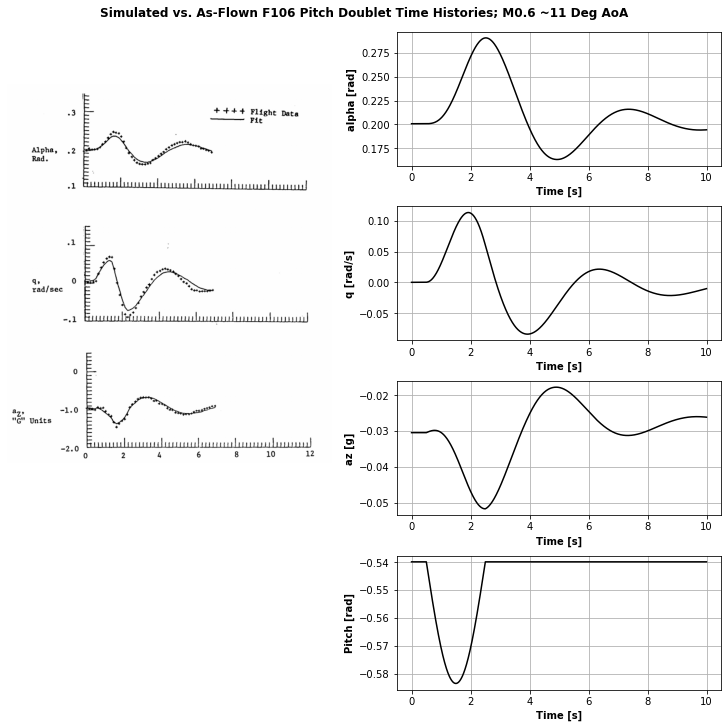

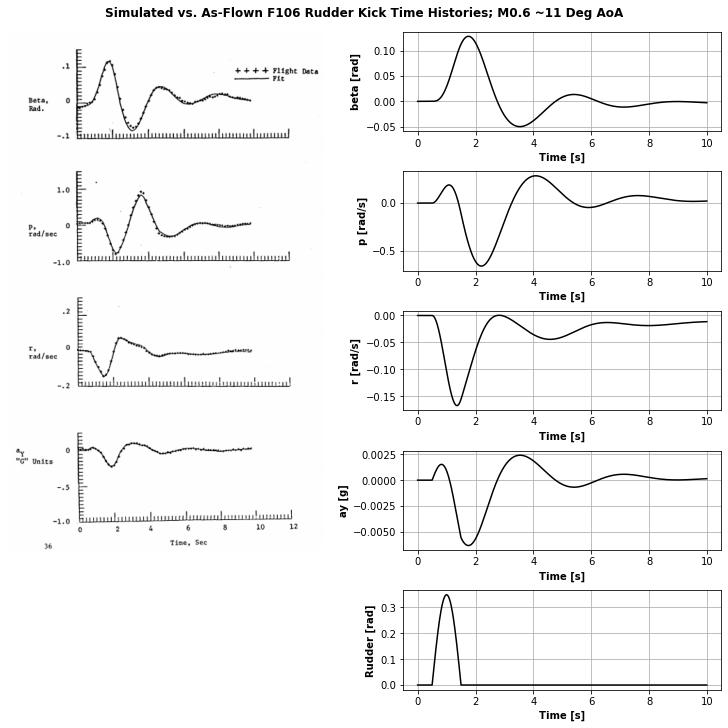

In [7]:


from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Output timesteps
dt = 0.01
T = 10.0
time = np.arange(0, T, dt)

#################
# Pitch Doublet #
#################
pitch_start = 0.5
Tpitch = 2.0
dpitch = 2.5/57.3
pitch_history = lambda t, x: delta0_rad - dpitch*np.sin(np.pi*(t - pitch_start)/Tpitch)*(t > pitch_start)*(t < (pitch_start + Tpitch))

f106.set_aero_controls(pitch = pitch_history)

eom = lambda t, x: eom_6dof(t, x, f106)

sol = solve_ivp(eom, [0, T], trim_X0, t_eval = time)
u, v, w, p, q, r, phi, theta, psi, Xe, Ye, Ze = sol.y
outputs = np.array([eom_6dof(ti, yi, f106, output_mode = True) for ti, yi in zip(time, sol.y.T)]).T
V, alpha, beta, p, q, r, phi, theta, psi, xe, ye, ze,  ax, ay, az, roll_control, pitch_control, yaw_control = outputs

lstyle = 'k-'
fig, ax = plt.subplot_mosaic([['image', 'alpha [rad]'],
                              ['image', 'q [rad/s]',],
                              ['image', 'az [g]'],
                              ['placehold', 'Pitch [rad]']],
                            figsize = (10, 10), 
                            constrained_layout = True)


ax['alpha [rad]'].plot(sol.t, alpha, lstyle)
ax['q [rad/s]'].plot(sol.t, q, lstyle)
ax['az [g]'].plot(sol.t, az/G_FT_S2, lstyle)
ax['Pitch [rad]'].plot(sol.t, pitch_control, lstyle)

for key, a in ax.items():
    if key == 'image':
        continue
    a.set_xlabel('Time [s]', fontweight = 'bold')
    a.set_ylabel(key, fontweight = 'bold')
    a.grid()

# Read & plot image + add annotations
image = plt.imread('images/f106_pitch_doublet.png')
ax['image'].imshow(image)
ax['image'].axis('off')
ax['placehold'].axis('off')

fig.suptitle('Simulated vs. As-Flown F106 Pitch Doublet Time Histories; M0.6 ~11 Deg AoA', fontweight = 'bold') 

###############
# Rudder Kick #
###############
rudder_start = 0.5
Trudder = 1.0
drudder = 20/57.3
yaw_history = lambda t, x: drudder*np.sin(np.pi*(t - rudder_start)/Trudder)*(t > rudder_start)*(t < (rudder_start + Trudder))
pitch_history = lambda t, x: delta0_rad

f106.set_aero_controls(pitch = pitch_history, 
                       yaw = yaw_history)

eom = lambda t, x: eom_6dof(t, x, f106)

sol = solve_ivp(eom, [0, T], trim_X0, t_eval = time)
u, v, w, p, q, r, phi, theta, psi, Xe, Ye, Ze = sol.y
outputs = np.array([eom_6dof(ti, yi, f106, output_mode = True) for ti, yi in zip(time, sol.y.T)]).T
V, alpha, beta, p, q, r, phi, theta, psi, xe, ye, ze,  ax, ay, az, roll_control, pitch_control, yaw_control = outputs

lstyle = 'k-'
fig, ax = plt.subplot_mosaic([['image', 'beta [rad]'],
                              ['image', 'p [rad/s]',],
                              ['image', 'r [rad/s]', ],
                              ['image', 'ay [g]'],
                              ['placehold', 'Rudder [rad]']],
                            figsize = (10, 10), 
                            constrained_layout = True)


ax['beta [rad]'].plot(sol.t, beta, lstyle)
ax['p [rad/s]'].plot(sol.t, p, lstyle)
ax['r [rad/s]'].plot(sol.t, r, lstyle)
ax['ay [g]'].plot(sol.t, ay/G_FT_S2, lstyle)
ax['Rudder [rad]'].plot(sol.t, yaw_control, lstyle)


for key, a in ax.items():
    if key == 'image':
        continue
    a.set_xlabel('Time [s]', fontweight = 'bold')
    a.set_ylabel(key, fontweight = 'bold')
    a.grid()

# Read & plot image + add annotations
image = plt.imread('images/f106_yaw_doublet.png')
ax['image'].imshow(image)
ax['image'].axis('off')
ax['placehold'].axis('off')

fig.suptitle('Simulated vs. As-Flown F106 Rudder Kick Time Histories; M0.6 ~11 Deg AoA', fontweight = 'bold') 



Neither history shows perfect agreement; in particular the "return" overshoot of pitch rate and roll rate looks much lower than the published data. However, since we don't know the actual input histories, it's difficult to say whether this is an issue with the model or with the input. The basic response dynamics are clearly being reflected well, so we'll consider this sufficient to use to move onto the next topic, which is linearization of the nonlinear flight dynamics. 